# Low-Inertia Frequency Stability
Adapted from the [ANDES documentation tutorial](https://docs.andes.app/en/latest/gallery/low-inertia-freq.html)

This notebook quantifies the relationship between system inertia and frequency stability on the IEEE 14-bus system (5 GENROU generators with AVR and governor controls) by:

1. Scaling the inertia constants of all generators by a factor 
 to emulate progressive renewable penetration.

2. Tripping the largest generator at each inertia level and recording the rotor speed transient.

3. Computing the center-of-inertia (COI) frequency and comparing RoCoF and nadir across scenarios.

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import andes

andes.config_logger(stream_level=30)

# System Setup
The IEEE 14-bus system contains five GENROU synchronous generators equipped with AVR exciters and turbine governors. The presence of these controllers produces well-damped transient responses that clearly illustrate the effect of inertia on frequency dynamics.

In [2]:
case_path = andes.get_case("ieee14/ieee14_full.xlsx")
ss_ref = andes.load(case_path)
ss_ref.PFlow.run()

gen_idxs = list(ss_ref.GENROU.idx.v)
gen_buses = list(ss_ref.GENROU.bus.v)
M_base = ss_ref.GENROU.M.v.copy()

gen_info = pd.DataFrame({"gen_idx": gen_idxs, "bus": gen_buses, "M": M_base})
gen_info.sort_values("M", ascending=False)


,gen_idx,bus,M
1,GENROU_2,2,13.0
2,GENROU_3,3,10.0
3,GENROU_4,6,10.0
4,GENROU_5,8,10.0
0,GENROU_1,1,8.0


# Frequency Response Under Varying Inertia
- Trip the largest generator by inertia @ 1s using a `Toggle` device
- Simulate 7 inertia scaling factors from $\alpha = 1.0$ to $\alpha = 0.15$
- Inertia constant $M$ of each generator is scaled by $\alpha$ before each time-domain run

In [39]:
trip_idx = gen_idxs[int(np.argmax(M_base))]

inertia_scales = [1.8, 0.8, 0.2]
results = {}

for alpha in inertia_scales:
    ss = andes.load(case_path, setup=False)
    ss.add("Toggle", model="GENROU", dev=trip_idx, t=1.0)
    ss.setup()
    ss.config.warn_abnormal = 1
    ss.GENROU.M.v[:] = M_base * alpha

    ss.PFlow.run()
    ss.TDS.config.tf = 8
    #ss.TDS.config.no_tqdm = 1
    ss.TDS.run()

    results[alpha] = ss.TDS.get_timeseries(ss.GENROU.omega)

  0%|          | 0/100 [00:00<?, ?%/s]

Violated stability criteria. To turn off, set [TDS].criteria = 0.
Simulation terminated at t=3.9668 s.


  0%|          | 0/100 [00:00<?, ?%/s]

Violated stability criteria. To turn off, set [TDS].criteria = 0.
Simulation terminated at t=3.4001 s.


  0%|          | 0/100 [00:00<?, ?%/s]

Violated stability criteria. To turn off, set [TDS].criteria = 0.
Simulation terminated at t=3.0334 s.


# COI Frequency After Generator Trip
Inertia-weighted average of all generator rotor speeds

$f_{COI} = (\sum_i \frac{M_i}{\sum_jM_j}\omega_i)\times 60 \text{Hz}$

Since the swing eq. relates $M_i \frac{d\omega_i}{dt}$ to the power imabalance at each machine, the COI frequency directly reflects the aggregate generation-load mismatch following the disturbance.

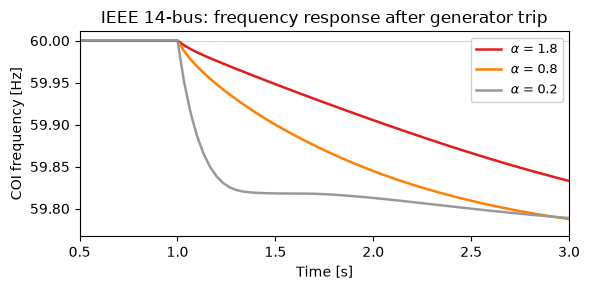

In [42]:
# plotting
weights = M_base / M_base.sum()
cmap = plt.cm.Set1

fig, ax = plt.subplots(figsize=(6, 3))

for i, (alpha, omega_df) in enumerate(results.items()):
    f_coi = (omega_df.values * weights).sum(axis=1) * 60
    color = cmap(i / (len(results) - 1))
    ax.plot(omega_df.index, f_coi, color=color, linewidth=1.8,
            label=f"$\\alpha$ = {alpha}")

ax.set_xlabel("Time [s]")
ax.set_ylabel("COI frequency [Hz]")
ax.set_title("IEEE 14-bus: frequency response after generator trip")
ax.legend(loc="upper right", fontsize=9, framealpha=0.9)
ax.set_xlim(0.5, 3.0)
ax.axhline(60.0, color="black", linewidth=0.4, alpha=0.3)

plt.tight_layout()

# Quantitative Metrics
- Nadir: minimum COI frequency reached before governor action arrests the decline
- RoCoF: maximum absolute rate of frequency change w/in the first second after the disturbance

In [5]:
metrics = []
for alpha, omega_df in results.items():
    f_coi = (omega_df.values * weights).sum(axis=1) * 60
    t = omega_df.index.values

    nadir = f_coi[t > 1.0].min()

    post = (t >= 1.0) & (t <= 2.0)
    t_post, f_post = t[post], f_coi[post]
    rocof = np.max(np.abs(np.diff(f_post) / np.diff(t_post)))

    metrics.append({"α": alpha, "Nadir [Hz]": nadir, "RoCoF [Hz/s]": rocof})

metrics_df = pd.DataFrame(metrics).set_index("α")
metrics_df

,Nadir [Hz],RoCoF [Hz/s]
α,,
1.00,59.778165,0.297080
0.70,59.778440,0.423739
0.50,59.781772,0.592006
0.40,59.784452,0.738667
0.30,59.787203,0.981922
0.20,59.788729,1.464048
0.15,59.789606,1.940406


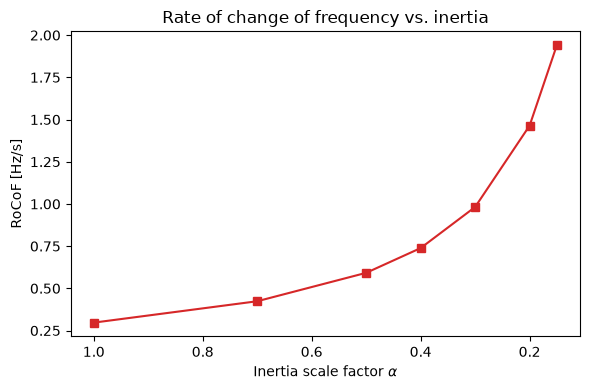

In [6]:
# RoCoF vs. inertia level
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(metrics_df.index, metrics_df["RoCoF [Hz/s]"], "s-", color="tab:red",
        markersize=6)
ax.set_xlabel("Inertia scale factor $\\alpha$")
ax.set_ylabel("RoCoF [Hz/s]")
ax.set_title("Rate of change of frequency vs. inertia")
ax.invert_xaxis()

plt.tight_layout()

Reducing the system inertia monotonically increases the RoCoF following the generator trip. From 
to $\alpha = 1.0$ to $\alpha =0.15$, the RoCoF increases by approximately six times. Although the IEEE 14-bus system is small, the same qualitative behavior applies to larger interconnections: as synchronous generation is displaced by inverter-based resources without synthetic inertia, the system frequency becomes increasingly vulnerable to sudden imbalances.